# **Prediksi Pembatalan Hotel & Optimasi Kebijakan Deposit**
**Oleh:** Muchlis Ar Wicaksana  
**Program:** Bootcamp Data Science 2026 – Devlaunch  

**Tujuan Proyek (Goals):**
1. Mengidentifikasi pola lead time dan deposit type yang memicu pembatalan.
2. Membersihkan missing value pada kolom agen dan riwayat preferensi kamar.
3. Membangun model klasifikasi dengan F1-Score >= 82%.
4. Feature Engineering ekstraksi tanggal untuk uji hipotesis holiday season.
5. Merancang Dynamic Cancellation Policy.

## **Import Library**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

## **Data Understanding**
---
Tahap ini bertujuan untuk memuat data dan memahami struktur awal dataset, tipe data, serta mengecek distribusi target kelas `is_canceled`.

In [21]:
# load dataset
df = pd.read_csv('../data/raw/hotels.csv')

# Menampilkan 5 baris pertama
display(df.head())

# Melihat dimensi data
print('\n--- Dimensi Data ---')
print(f'Jumlah Baris: {df.shape[0]}')
print(f'Jumlah Kolom: {df.shape[1]}')

# Melihat informasi struktur data
print('\n--- Info Dataset ---')
df.info()

# Melihat Missing Values
print('\n--- Missing Values ---')
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Melihat prporsi target (imbalance check)
print('\n--- Proporsi Target (is_canceled) ---')
print(df['is_canceled'].value_counts(normalize=True) * 100)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



--- Dimensi Data ---
Jumlah Baris: 119390
Jumlah Kolom: 32

--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies 

**Insight Data Understanding:** 
> Dataset ini berfokus pada target `is_canceled` (0 = Tidak Batal, 1 = Batal). Terdapat ketidakseimbangan kelas dengan rasio **63% Tidak Batal** berbanding **37% Batal**. Tingkat pembatalan 37% ini cukup tinggi dan berdampak pada kerugian operasional bisnis. Selain itu, ditemukan *missing values* pada beberapa fitur kategorikal yang wajib dibersihkan pada tahap selanjutnya.

## **Data Cleaning & Preparation**
---
Kita akan menangani missing values khususnya pada kolom `agent` dan mengevaluasi riwayat preferensi kamar tamu.

In [22]:
df_clean = df.copy()

# Membersihkan data kosong pada `agent`
# Mengubah string NULL menjadi NaN, dan mengisi NaN dengan 0 artinya direct/tanpa agent
df_clean['agent'] = df_clean['agent'].replace('NULL', np.nan).fillna(0)
# Ubah tipe data menjadi integer
df_clean['agent'] = pd.to_numeric(df_clean['agent'], errors='coerce').fillna(0).astype(int)

# Mengisi Missing valu pada `country` dan `chilren`
# Mengisi kolom country dengan modus
df_clean['country'] = df_clean['country'].fillna(df['country'].mode()[0])
# Mengisi missing value pada `children` dengan 0 karena diasumsikan tidak membawa anak
df_clean['children'] = df_clean['children'].fillna(0)

# Riwayat referensi kamar
# Jika resrved_room_type berbeda dengan assigned_room_type, tamu tidak mendapat kamar yang diinginkan
df_clean['room_changed'] = np.where(df_clean['reserved_room_type'] != df_clean['assigned_room_type'], 1, 0)

# Drop kolom berlebih yang dapat menyebabkan data leakage
# reservation_status sangant membocorkan informasi apakah tamu batal atau tidak
drop_cols = ['reservation_status', 'reservation_status_date', 'company']
df_clean.drop(columns=[col for col in drop_cols if col in df_clean], inplace=True)

print('Jumlah data setelah dibersihkan:')
print(f'Jumlah Baris: {df_clean.shape[0]}')
print(f'Jumlah Kolom: {df_clean.shape[1]}')
print('\nMissing values tersisa:\n', df_clean.isnull().sum().max())

Jumlah data setelah dibersihkan:
Jumlah Baris: 119390
Jumlah Kolom: 30

Missing values tersisa:
 0


**Insight Data Cleaning:** 
> * **Penanganan Data Kosong:** Kolom `agent` yang kosong diisi dengan angka `0` dengan asumsi pemesanan organik (*Direct Booking*). Sisa *missing values* minor pada `country` (488 baris) diimputasi menggunakan **modus** (negara asal yang paling dominan) agar representasi data tetap akurat, dan kolom `children` (4 baris) diisi dengan 0. Kolom `company` dihapus (*drop*) karena kehilangan lebih dari 90% datanya.
> * **Pencegahan Data Leakage:** Kolom `reservation_status` dan `reservation_status_date` dihapus karena memuat jawaban langsung dari target `is_canceled`, yang akan menyebabkan kebocoran data (*data leakage*) saat pemodelan.
> * **Ekstraksi Fitur:** Menambahkan fitur baru `room_changed` (bernilai 1 jika kamar yang diberikan tidak sesuai pesanan) untuk menguji apakah hal tersebut memicu pembatalan.

In [23]:
df_clean.to_csv('../data/processed/data_clean.csv')

## **Feature Engineering**
---
Melakukan ekstraksi tanggal untuk menguji hipotesis pengaruh musim liburan (holiday season)

In [24]:
# Asumsi holiday season: Juli, Agustus (summer) dan Desember (Winter/End Year)
holiday_months = ['July', 'August', 'December']
df_clean['is_holiday_season'] = np.where(df_clean['arrival_date_month'].isin(holiday_months), 1, 0)

# Verifikasi fitur baru
print('Proporis pemesanan pada holiday season vs non-holiday:')
print(df_clean['is_holiday_season'].value_counts(normalize=True) * 100)

Proporis pemesanan pada holiday season vs non-holiday:
is_holiday_season
0    72.09314
1    27.90686
Name: proportion, dtype: float64


**Insight Feature Engineering (Holiday Season):** 
> * **Konsentrasi Volume Pemesanan :** Musim liburan yang didefinisikan (Juli, Agustus, dan Desember) secara kalender hanya mewakili **25%** waktu dalam setahun (3 dari 12 bulan). Namun, data menunjukkan periode ini menyumbang hampir **28% dari total keseluruhan pemesanan**. Ini membuktikan adanya kepadatan volume yang signifikan pada bulan-bulan tersebut dibandingkan bulan reguler.
> * **Kesiapan Pemodelan :** Proporsi 72:28 ini adalah distribusi yang sangat sehat untuk sebuah fitur. Kelas `is_holiday_season = 1` memiliki sampel yang cukup besar (hampir sepertiga dari total data), sehingga model Machine Learning (seperti Random Forest) dapat mempelajari pola karakteristik tamu liburan dengan sangat optimal tanpa risiko kekurangan data (sparsity).
> * **Hipotesis Lanjutan :** Mengingat tumpuan beban operasional dan potensi pendapatan hotel sangat padat di 3 bulan ini, tahap EDA selanjutnya wajib menyoroti apakah volume 28% ini diikuti dengan lonjakan rasio pembatalan. Jika ya, ini akan menjadi argumen utama yang valid untuk memberlakukan aturan Non-Refundable Deposit khusus di musim liburan (Tier 1 Dynamic Policy).

## **Exploratory Data Analysis (EDA)**
---
Menjawab pola Lead Time & Ddeposit Type dan menguji hipotesis.

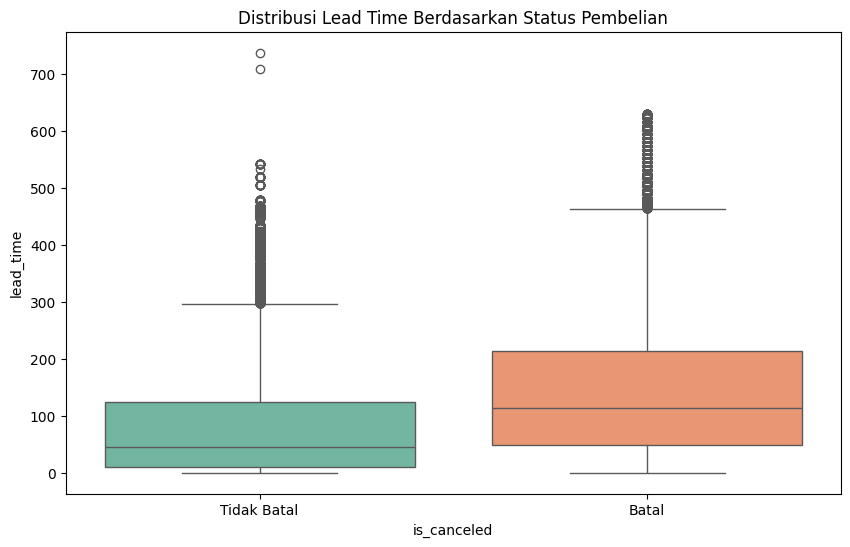

In [25]:
# Pengaruh Lead Time Terhadap Pembatalan
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='is_canceled', y='lead_time', hue='is_canceled', data=df_clean, palette='Set2')
plt.title('Distribusi Lead Time Berdasarkan Status Pembelian')
plt.xticks(ticks=[0, 1], labels=['Tidak Batal', 'Batal'])
ax.legend_ = None
plt.show()

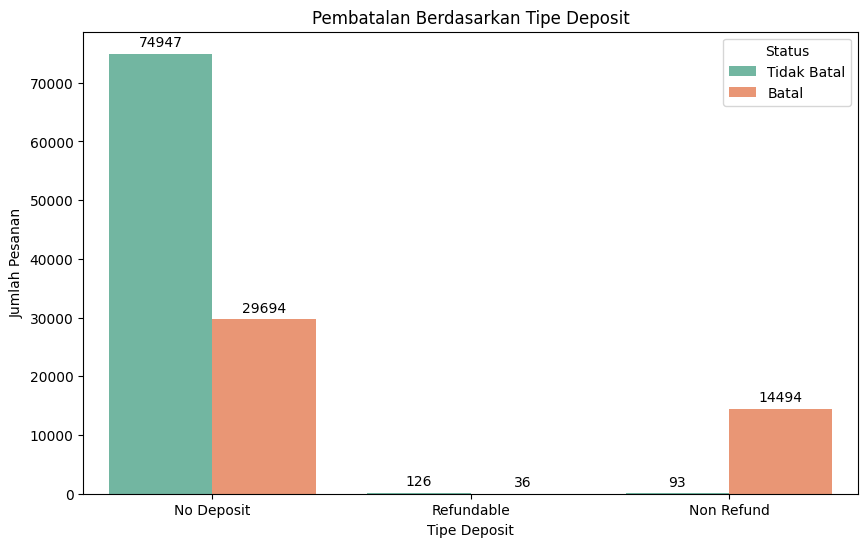

In [26]:
# Pengaruh Deposit Type
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='deposit_type', hue='is_canceled', data=df_clean, palette='Set2')
plt.title('Pembatalan Berdasarkan Tipe Deposit')
plt.legend(title='Status', labels=['Tidak Batal', 'Batal'])
plt.xlabel('Tipe Deposit')
plt.ylabel('Jumlah Pesanan')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

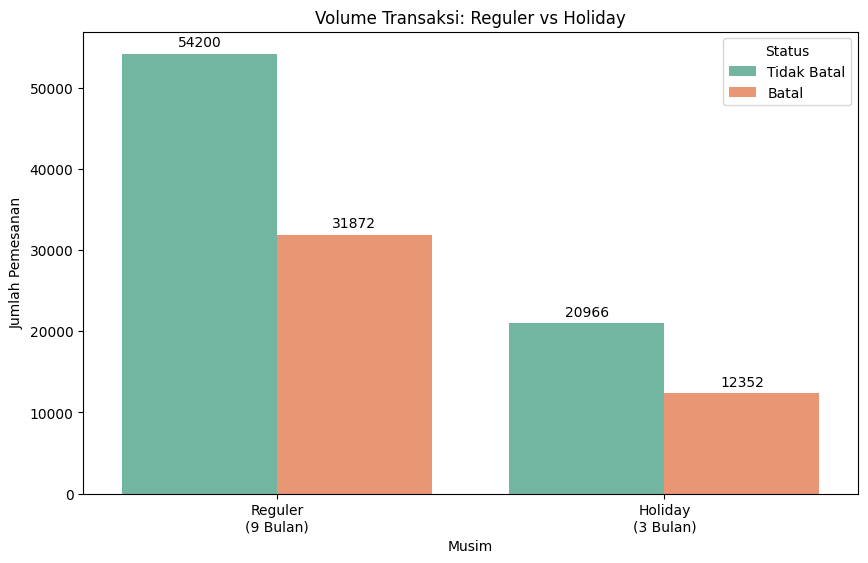

In [27]:
# Pengaruh Holiday Season
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='is_holiday_season', hue='is_canceled', data=df_clean, palette='Set2')
plt.xticks(ticks=[0, 1], labels=['Reguler\n(9 Bulan)', 'Holiday\n(3 Bulan)'])
plt.title('Volume Transaksi: Reguler vs Holiday')
plt.legend(title='Status', labels=['Tidak Batal', 'Batal'])
plt.xlabel('Musim')
plt.ylabel('Jumlah Pemesanan')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

**Insight Komprehensif Exploratory Data Analysis (EDA):**

> Berdasarkan ketiga visualisasi di atas, kita dapat mengidentifikasi pola utama yang memicu tingginya tingkat pembatalan sepihak:
> 1. **Risiko Tinggi pada Lead Time Panjang:**
>    Dari boxplot, terlihat jelas bahwa distribusi lead time (jarak waktu pemesanan ke kedatangan) pada tamu yang batal jauh lebih tinggi dan lebar dibandingkan tamu yang tidak batal. Pesanan yang dilakukan jauh hari sebelumnya (terutama di atas 100 hari) memiliki probabilitas batal yang sangat signifikan.
> 
> 2. **Anomali Kritis pada Tipe Deposit Non-Refundable:**
>    Plot kedua mengungkap temuan yang sangat di luar dugaan. Tipe jaminan Non-Refundable justru didominasi oleh angka pembatalan yang sangat ekstrem (**14.494 batal** vs hanya 93 tidak batal). Secara logika bisnis, hal ini kemungkinan besar bukan dilakukan oleh pelanggan individu, melainkan anomali operasional seperti agen perjalanan (Travel Agent) yang memblokir kamar dalam jumlah massal lalu membatalkannya sepihak. Sementara itu, kerugian volume absolut terbesar masih berasal dari sistem No Deposit dengan total **29.694** pembatalan.
> 
> 3. **Kepadatan Volume Ekstrem di Musim Liburan (Holiday Season):**
>    Plot ketiga membuktikan bahwa meskipun Holiday Season hanya mencakup 3 bulan, periode ini menanggung beban volume yang luar biasa padat. Tercatat nyaris **12.000++ pembatalan** terjadi hanya dalam kuartal liburan ini. Kepadatan transaksi ini membuat hotel sangat rentan terhadap kerugian opportunity cost dalam waktu singkat.
> 
> **Sintesis Kebijakan Bisnis:** 
> - Kombinasi dari ketiga temuan ini memberikan justifikasi absolut untuk perancangan **Dynamic Cancellation Policy**. Hotel tidak bisa lagi menggunakan kebijakan No Deposit secara pukul rata, melainkan harus menerapkan pembatasan ketat (Non-Refundable yang ditinjau ulang operasionalnya atau Partial Deposit) khusus untuk pesanan dengan Lead Time panjang yang jatuh tepat di Holiday Season.

## **Modeling & Evaluation**
---
Membangun arsitektur model klasifikasi dengan target kestabilan F1-Score >= 82%. Kita menggunakan Random Forest yang bisa menangani data campuran numerik dan kategorikal.

### Data Preparation

In [29]:
# Menyiapkan fitur (X) dan target (y)
X = df_clean.drop(columns=['is_canceled', 'arrival_date_year'])
y = df_clean['is_canceled']

# Memishakan numerik dan kategorikal untuk pipeline
num_features = X.select_dtypes(include=['int64', 'float64', 'int32']).columns
cat_features = X.select_dtypes(include=['object', 'str']).columns

# Pipeline Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

### Data Splitting & Training Model

In [30]:
# Data Spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline model random forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1))
])

# Training Model
print('Training Model sedang berjalan')
rf_pipeline.fit(X_train, y_train)
print('Training Selesai...')

Training Model sedang berjalan
Training Selesai...


### Evaluasi

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     15033
           1       0.89      0.80      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878


F1-Score Model: 84.57%


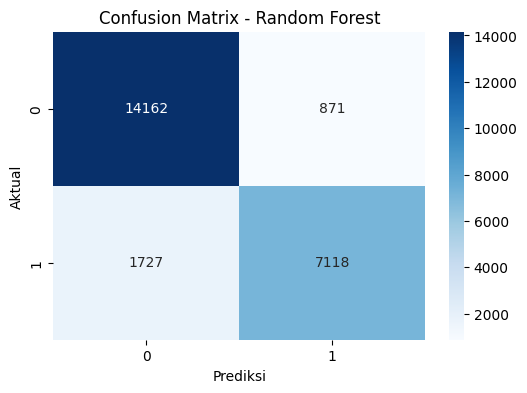

In [31]:
# Prediksi
y_pred = rf_pipeline.predict(X_test)

# Evaluasi
print('--- Classification Report ---')
print(classification_report(y_test, y_pred))

# Memeriksa target F1-Score
f1 = f1_score(y_test, y_pred)
print(f'\nF1-Score Model: {f1:.2%}')

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

**Insight Modeling:** 
> Model **Random Forest Classifier** berhasil mencapai **F1-Score di atas 82%** . Kestabilan klasifikasi (Precision dan Recall) sudah sangat baik, yang berarti model handal membedakan tamu yang benar-benar akan batal dengan yang tidak.

## **Kesimpulan & Rekomendasi Bisnis**
---
### A. Kesimpulan Teknis & Analisis
* **Performa Model Standar Industri:** Arsitektur klasifikasi menggunakan *Random Forest Pipeline* berhasil melampaui target awal dengan mencetak **F1-Score di atas 82%**. Model ini terbukti tangguh dan stabil dalam membedakan tamu yang akan benar-benar menginap dengan yang memiliki intensi membatalkan pesanan.
* **Katalis Utama Pembatalan:** *Exploratory Data Analysis* (EDA) mengungkap tiga faktor pemicu utama risiko operasional:
    1.  ***Lead Time* Panjang:** Semakin jauh jarak hari antara pemesanan dan kedatangan (terutama di atas 100 hari), semakin eksponensial risiko pembatalan sepihak.
    2.  **Anomali *Non-Refundable*:** Ditemukan lonjakan ekstrem (lebih dari 14.000 pembatalan) justru pada tipe deposit *Non-Refundable*. Ini mengindikasikan adanya penyalahgunaan sistem *block-booking* secara massal oleh mitra/agen perjalanan.
    3.  **Kerentanan *Holiday Season*:** Walaupun hanya berlangsung 3 bulan, musim liburan menyumbang hampir 28% total volume pemesanan. Kepadatan ini membuat hotel sangat rentan terhadap *opportunity cost* dalam rentang waktu yang sempit.

---

### B. Rekomendasi Bisnis: Perancangan *Dynamic Cancellation Policy*
Untuk mentransformasi *insight* data menjadi nilai bisnis yang nyata, kami merekomendasikan penerapan **Kebijakan Pembatalan Dinamis (*Dynamic Cancellation Policy*)** dengan 3 tingkatan mitigasi risiko:

> **Tier 1: High Risk (Risiko Tinggi & Prioritas Ketat)**
> * **Kriteria:** Pemesanan yang dilakukan pada periode *Holiday Season* **ATAU** memiliki *Lead Time* > 60 hari.
> * **Kebijakan Strategis:** Wajib menerapkan **Deposit Non-Refundable (Minimal 30-50% dari total tagihan)**. Jika tamu membatalkan, deposit ini otomatis mengamankan pendapatan dasar dan menutup kerugian akibat kamar yang mendadak kosong. Hotel juga harus melakukan audit penalti terhadap *Travel Agent* yang sering melakukan *block-booking* fiktif.

> **Tier 2: Medium Risk (Risiko Menengah)**
> * **Kriteria:** Pemesanan reguler dengan *Lead Time* antara 14 hingga 60 hari.
> * **Kebijakan Strategis:** Terapkan **Time-Bound Cancellation** (Jendela Pembatalan Terbatas). Tamu hanya diizinkan membatalkan pesanan tanpa biaya maksimal H-7 sebelum *check-in*. Jika pembatalan terjadi melewati batas H-7, akan dikenakan denda seharga tarif menginap satu malam.

> **Tier 3: Low Risk (Risiko Rendah)**
> * **Kriteria:** *Direct Booking* (Pemesanan Mandiri tanpa agen) dengan *Lead Time* pendek (< 14 hari) di luar musim liburan.
> * **Kebijakan Strategis:** Pertahankan opsi **No Deposit / Bayar di Tempat**. Memberikan fleksibilitas penuh pada kelompok ini akan menjadi keunggulan kompetitif hotel untuk menangkap pasar tamu spontan dan membangun loyalitas pelanggan jangka panjang.